In [ ]:
# Cell 1: Enhanced Imports and Setup for Single Dataset Model Comparison
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
import glob
import os
from geopy.distance import geodesic
import joblib
# Enhanced feature engineering
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression
# Additional imports for mapping and visualization
import folium
from folium import plugins
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
# Coordinate transformation
from pyproj import Transformer
import json
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Cell 2: Discover and Select Single Training Set for Model Comparison
base_path = 'smartphone-decimeter-2023/sdc2023/train/'
drive_sets = []
for drive in glob.glob(os.path.join(base_path, '*')):
    if not os.path.isdir(drive):
        continue
    for phone in glob.glob(os.path.join(drive, '*')):
        if not os.path.isdir(phone):
            continue
        gnss = os.path.join(phone, 'device_gnss.csv')
        imu = os.path.join(phone, 'device_imu.csv')
        gt = os.path.join(phone, 'ground_truth.csv')
        if os.path.exists(gnss) and os.path.exists(imu) and os.path.exists(gt):
            drive_sets.append({'gnss': gnss, 'imu': imu, 'gt': gt, 'drive': drive, 'phone': phone})

print(f"Found {len(drive_sets)} drive/phone sets with all required files.")

# Select only the first valid dataset for model comparison
if len(drive_sets) > 0:
    selected_drive_set = drive_sets[0]
    print(f"\n✅ Selected for model comparison:")
    print(f"   Date: {os.path.basename(selected_drive_set['drive'])}")
    print(f"   Phone: {os.path.basename(selected_drive_set['phone'])}")
    print(f"   Focus: Single dataset, multiple model comparison")
else:
    print("❌ No valid datasets found!")

In [ ]:
# Cell 3: Find intersection of realistic features for multiple datasets (v6 approach with index range 1-10)

# These are the features actually available in your dataset (v6 exact method)
realistic_features = [
    # GNSS signal quality features
    'Cn0DbHz',              # Signal strength (SNR) - CRITICAL for quality
    'Svid',                 # Satellite ID
    'SvElevationDegrees',   # Satellite elevation - CRITICAL for atmospheric errors
    'SvAzimuthDegrees',     # Satellite azimuth
    'SpeedMps'
    
    # IMU features  
    'IMU_MessageType',      # IMU message type
    'MeasurementX',         # IMU X measurement
    'MeasurementY',         # IMU Y measurement  
    'MeasurementZ',         # IMU Z measurement
    
    # Bias corrections
    'BiasX',                # X bias
    'BiasY',                # Y bias
    'BiasZ',                # Z bias
    
    # WLS ECEF positions (calculated during training, will be calculated for test)
    'WlsPositionXEcefMeters',
    'WlsPositionYEcefMeters', 
    'WlsPositionZEcefMeters'
]

print(f"Realistic feature set: {len(realistic_features)} features")
print("✅ Using only features actually available in your dataset")
print("🎯 Focus: Cn0DbHz (signal strength) + SvElevationDegrees (atmospheric filtering)")
print("📍 Note: WLS ECEF positions calculated during training, will be calculated for test data")

# Process datasets with indexes 1-10 (range selection)
DATASET_START_INDEX = 1
DATASET_END_INDEX = 10

print(f"\n🎯 Processing datasets with indexes {DATASET_START_INDEX} through {DATASET_END_INDEX}")

selected_drive_sets = []
all_common_features = []

for idx in range(DATASET_START_INDEX, min(DATASET_END_INDEX + 1, len(drive_sets))):
    print(f"\n📂 Checking dataset index: {idx}")
    print(f"   Date: {os.path.basename(drive_sets[idx]['drive'])}")
    print(f"   Phone: {os.path.basename(drive_sets[idx]['phone'])}")
    
    try:
        ds = drive_sets[idx]
        gnss = pd.read_csv(ds['gnss'], nrows=1, low_memory=False)
        imu = pd.read_csv(ds['imu'], nrows=1)
        gt = pd.read_csv(ds['gt'], nrows=1)

        if 'MessageType' in imu.columns:
            imu = imu.rename(columns={'MessageType': 'IMU_MessageType'})

        merged_cols = set(gnss.columns) | set(imu.columns) | set(gt.columns)
        current_features = set([f for f in realistic_features if f in merged_cols])
        
        print(f"   Available features: {len(current_features)}")
        
        if len(current_features) >= 10:  # Minimum feature threshold
            selected_drive_sets.append(ds)
            all_common_features.append(list(current_features))
            print(f"   ✅ Selected (features: {len(current_features)})")
        else:
            print(f"   ❌ Skipped (insufficient features: {len(current_features)})")
        
    except Exception as e:
        print(f"   ❌ Error reading dataset: {e}")

if selected_drive_sets:
    # Find intersection of features across all selected datasets
    common_features = list(set.intersection(*[set(features) for features in all_common_features]))
    
    print(f"\n✅ SELECTED DATASETS SUMMARY:")
    print(f"   Total datasets selected: {len(selected_drive_sets)}")
    print(f"   Index range: {DATASET_START_INDEX}-{min(DATASET_END_INDEX, len(drive_sets)-1)}")
    print(f"   Common features across all datasets: {len(common_features)}")
    print(f"   Features: {sorted(common_features)}")
    
    print(f"\n📊 DATASET DETAILS:")
    for i, ds in enumerate(selected_drive_sets):
        print(f"   {DATASET_START_INDEX + i}: {os.path.basename(ds['drive'])}")
        
else:
    print(f"❌ No suitable datasets found in index range {DATASET_START_INDEX}-{DATASET_END_INDEX}")
    # Use basic features as fallback
    basic_features = ['Cn0DbHz', 'Svid', 'SvElevationDegrees', 'SvAzimuthDegrees',
                     'WlsPositionXEcefMeters', 'WlsPositionYEcefMeters', 'WlsPositionZEcefMeters']
    common_features = basic_features
    selected_drive_sets = drive_sets[DATASET_START_INDEX:DATASET_END_INDEX+1]
    print(f"Using basic features: {common_features}")

In [ ]:
# Cell 4: Enhanced Data Loading with Advanced Signal Quality Filtering (v6 Approach - Multiple Datasets)

def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate distance between two points on Earth using haversine formula"""
    return geodesic((lat1, lon1), (lat2, lon2)).meters

if 'common_features' in locals() and 'selected_drive_sets' in locals():
    print("🔧 Processing multiple selected datasets with v6 enhanced filtering...")
    
    # Coordinate transformer for ECEF to WGS84 (v6 approach)
    from pyproj import Transformer
    transformer = Transformer.from_crs("EPSG:4978", "EPSG:4326", always_xy=True)
    
    all_processed_data = []
    
    for dataset_idx, ds in enumerate(selected_drive_sets):
        print(f"\n📂 Processing dataset {DATASET_START_INDEX + dataset_idx}: {os.path.basename(ds['drive'])}")
        
        try:
            # Read CSV files with mixed type handling (v6 method)
            gnss = pd.read_csv(ds['gnss'], low_memory=False)
            imu = pd.read_csv(ds['imu'])
            gt = pd.read_csv(ds['gt'])
            
            print(f"   Loaded: GNSS={len(gnss):,}, IMU={len(imu):,}, GT={len(gt):,}")
            
            # Standardize column names (v6 exact method)
            if 'UnixTimeMillis' in gnss.columns:
                gnss = gnss.rename(columns={'UnixTimeMillis': 'utcTimeMillis'})
            if 'UnixTimeMillis' in imu.columns:
                imu = imu.rename(columns={'UnixTimeMillis': 'utcTimeMillis'})
            if 'UnixTimeMillis' in gt.columns:
                gt = gt.rename(columns={'UnixTimeMillis': 'utcTimeMillis'})
            if 'MessageType' in imu.columns:
                imu.rename(columns={'MessageType': 'IMU_MessageType'}, inplace=True)

            # Merge GNSS and IMU (v6 approach)
            gnss_imu = pd.merge_asof(
                gnss.sort_values('utcTimeMillis'),
                imu.sort_values('utcTimeMillis'),
                on='utcTimeMillis',
                direction='nearest',
                tolerance=50  # Tighter tolerance for better sync
            )
            
            print(f"   After GNSS-IMU merge: {len(gnss_imu):,}")

            # Merge with ground truth (v6 approach)
            data = pd.merge_asof(
                gnss_imu.sort_values('utcTimeMillis'),
                gt.sort_values('utcTimeMillis'),
                on='utcTimeMillis',
                direction='nearest',
                tolerance=50  # Tighter tolerance
            ).dropna(subset=['LatitudeDegrees', 'LongitudeDegrees'])
            
            print(f"   After Ground Truth merge: {len(data):,}")
            
            total_samples = len(data)
            
            # Enhanced signal quality filtering for high precision (v6 method)
            quality_filters = []
            
            # 1. Strong signal strength (Cn0DbHz > 40 for high precision)
            if 'Cn0DbHz' in data.columns:
                quality_filters.append(data['Cn0DbHz'] > 40)
                print("   ✅ Applied Cn0DbHz > 40 filter")
            
            # 2. High satellite elevation (> 20 degrees to reduce atmospheric errors)
            if 'SvElevationDegrees' in data.columns:
                quality_filters.append(data['SvElevationDegrees'] > 20)
                print("   ✅ Applied SvElevationDegrees > 20 filter")
            
            # 3. Valid ECEF coordinates (v6 method)
            valid_ecef = (
                (data['WlsPositionXEcefMeters'] != 0) & 
                (data['WlsPositionYEcefMeters'] != 0) & 
                (data['WlsPositionZEcefMeters'] != 0) &
                data['WlsPositionXEcefMeters'].notna() &
                data['WlsPositionYEcefMeters'].notna() &
                data['WlsPositionZEcefMeters'].notna()
            )
            quality_filters.append(valid_ecef)
            print("   ✅ Applied valid ECEF coordinates filter")
            
            # Combine all quality filters
            if quality_filters:
                high_quality_mask = np.logical_and.reduce(quality_filters)
                data = data[high_quality_mask]
            
            high_quality_samples = len(data)
            print(f"   High-quality samples: {high_quality_samples:,} ({100*high_quality_samples/total_samples:.1f}% retained)")
            
            if len(data) > 0:
                # Add dataset identifier
                data['dataset_id'] = dataset_idx
                all_processed_data.append(data)
                print(f"   ✅ Dataset processed successfully")
            else:
                print(f"   ❌ No high-quality data remaining after filtering")
                
        except Exception as e:
            print(f"   ❌ Error processing dataset: {e}")
    
    if all_processed_data:
        # Combine all processed datasets
        X_all = pd.concat(all_processed_data, ignore_index=True)
        print(f"\n✅ COMBINED DATASET SUMMARY:")
        print(f"   Total datasets processed: {len(all_processed_data)}")
        print(f"   Combined samples: {len(X_all):,}")
        print(f"   Features available: {[f for f in common_features if f in X_all.columns]}")
        print("✅ Enhanced data loading with v6 filtering complete")
    else:
        print("❌ No datasets were successfully processed")
        
else:
    print("❌ No features or datasets available for processing")

In [ ]:
# Cell 5: Coordinate Transformation and Feature Engineering (v6 Approach)

if 'X_all' in locals() and len(X_all) > 0:
    print("🎯 Converting coordinates and calculating correction targets (v6 approach)...")
    
    # Convert WLS ECEF positions to Lat/Lng (v6 exact method)
    wls_coords = transformer.transform(
        X_all['WlsPositionXEcefMeters'].values,
        X_all['WlsPositionYEcefMeters'].values,
        X_all['WlsPositionZEcefMeters'].values
    )
    wls_lat = wls_coords[1]
    wls_lng = wls_coords[0]
    
    print(f"✅ Converted {len(wls_lat)} WLS ECEF positions to lat/lng")
    
    # Validate coordinate transformations (v6 method)
    valid_coords = (
        np.isfinite(wls_lat) & np.isfinite(wls_lng) &
        (np.abs(wls_lat) <= 90) & (np.abs(wls_lng) <= 180)
    )
    
    if not np.any(valid_coords):
        print("❌ No valid coordinates after transformation")
    else:
        X_all = X_all[valid_coords]
        wls_lat = wls_lat[valid_coords]
        wls_lng = wls_lng[valid_coords]
        
        # Calculate GPS corrections (v6 exact method)
        lat_corrections = X_all['LatitudeDegrees'].values - wls_lat
        lng_corrections = X_all['LongitudeDegrees'].values - wls_lng
        
        # Filter extreme corrections (likely outliers) - v6 approach
        correction_magnitude = np.sqrt(lat_corrections**2 + lng_corrections**2) * 111000  # meters
        reasonable_corrections = correction_magnitude < 500  # Less than 500m corrections
        
        valid_corrections = (
            np.isfinite(lat_corrections) & 
            np.isfinite(lng_corrections) &
            reasonable_corrections
        )
        
        if not np.any(valid_corrections):
            print("❌ No valid corrections after filtering")
        else:
            X_all = X_all[valid_corrections]
            lat_corrections = lat_corrections[valid_corrections]
            lng_corrections = lng_corrections[valid_corrections]
            
            print(f"Valid corrections: {len(lat_corrections):,}")
            print(f"Mean correction magnitude: {np.mean(correction_magnitude[valid_corrections]):.1f}m")

            # Extract enhanced features (v6 method)
            features = [f for f in common_features if f in X_all.columns]
            X_features = X_all[features].copy()
            
            # Create derived features for better precision (v6 approach)
            if 'Cn0DbHz' in X_features.columns and 'SvElevationDegrees' in X_features.columns:
                X_features['SignalQuality'] = X_features['Cn0DbHz'] * np.sin(np.radians(X_features['SvElevationDegrees']))
                print("✅ Created SignalQuality feature")
            
            if 'WlsPositionXEcefMeters' in X_features.columns:
                X_features['WLS_Distance'] = np.sqrt(
                    X_features['WlsPositionXEcefMeters']**2 + 
                    X_features['WlsPositionYEcefMeters']**2 + 
                    X_features['WlsPositionZEcefMeters']**2
                )
                print("✅ Created WLS_Distance feature")
            
            # Fill missing values (v6 approach)
            X_features = X_features.fillna(0)
            
            # Create target DataFrame (v6 method)
            y_all = pd.DataFrame({
                'LatCorrection': lat_corrections,
                'LngCorrection': lng_corrections
            })
            
            print(f"\n✅ V6 ENHANCED GPS CORRECTION APPROACH:")
            print(f"   Feature matrix: {X_features.shape}")
            print(f"   Target matrix: {y_all.shape}")
            print(f"   Features: {list(X_features.columns)}")
            print(f"   Target: Sub-10m accuracy GPS corrections")
            
else:
    print("❌ No processed data available for feature engineering")

In [ ]:
# Cell 6: Enhanced Data Preparation and Multiple Model Training with MultiOutputRegressor

if 'X_features' in locals() and 'y_all' in locals():
    print("🚀 Preparing data and training multiple models for GPS correction...")
    print("🎯 Using MultiOutputRegressor for simultaneous lat/lng prediction")
    
    # Advanced categorical encoding (v6 exact method)
    cat_cols = X_features.select_dtypes(include=['object']).columns.tolist()
    encoders = {}

    for col in cat_cols:
        le = LabelEncoder()
        X_features[col] = le.fit_transform(X_features[col].astype(str))
        encoders[col] = le
        print(f"✅ Encoded categorical feature: {col}")

    print(f"\nFinal dataset shape: {X_features.shape}")
    print(f"Target shape: {y_all.shape}")

    # Enhanced feature scaling with RobustScaler (v6 approach)
    print("\n⚡ Applying RobustScaler for enhanced feature scaling...")
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X_features)
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_all, test_size=0.2, random_state=42
    )
    
    print(f"Training set: {X_train.shape[0]:,} samples")
    print(f"Test set: {X_test.shape[0]:,} samples")
    
    # Import additional models suitable for GPS correction
    from sklearn.ensemble import ExtraTreesRegressor, AdaBoostRegressor
    from sklearn.linear_model import ElasticNet, Lasso, BayesianRidge, HuberRegressor
    from sklearn.svm import SVR
    from sklearn.neighbors import KNeighborsRegressor
    from sklearn.neural_network import MLPRegressor
    import warnings
    warnings.filterwarnings('ignore')
    
    # Define models with MultiOutputRegressor for GPS correction
    print("\n🎯 Training Multiple Models with MultiOutputRegressor...")
    print("📍 Each model predicts [Lat_Correction, Lng_Correction] simultaneously")
    
    models = {}
    
    # 1. Random Forest (v6 exact parameters)
    print("\n🌲 Training Random Forest...")
    models['Random Forest'] = MultiOutputRegressor(RandomForestRegressor(
        n_estimators=100, max_depth=15, min_samples_split=20, min_samples_leaf=10,
        max_features='sqrt', n_jobs=-1, random_state=42
    ))
    models['Random Forest'].fit(X_train, y_train)
    print("✅ Random Forest training complete")
    
    # 2. Extra Trees (more randomness, better generalization)
    print("\n🌳 Training Extra Trees...")
    models['Extra Trees'] = MultiOutputRegressor(ExtraTreesRegressor(
        n_estimators=100, max_depth=15, min_samples_split=20, min_samples_leaf=10,
        max_features='sqrt', n_jobs=-1, random_state=42
    ))
    models['Extra Trees'].fit(X_train, y_train)
    print("✅ Extra Trees training complete")
    
    # 3. Gradient Boosting (v6 enhanced)
    print("\n⚡ Training Gradient Boosting...")
    models['Gradient Boosting'] = MultiOutputRegressor(GradientBoostingRegressor(
        n_estimators=100, max_depth=8, learning_rate=0.15, subsample=0.8,
        min_samples_split=15, min_samples_leaf=8, max_features='sqrt', random_state=42
    ))
    models['Gradient Boosting'].fit(X_train, y_train)
    print("✅ Gradient Boosting training complete")
    
    # 4. Ridge Regression (L2 regularization)
    print("\n📏 Training Ridge Regression...")
    models['Ridge'] = MultiOutputRegressor(Ridge(alpha=1.0, random_state=42))
    models['Ridge'].fit(X_train, y_train)
    print("✅ Ridge Regression training complete")
    
    # 5. Lasso (L1 regularization, feature selection)
    print("\n📐 Training Lasso Regression...")
    models['Lasso'] = MultiOutputRegressor(Lasso(alpha=0.01, random_state=42))
    models['Lasso'].fit(X_train, y_train)
    print("✅ Lasso Regression training complete")
    
    # 6. ElasticNet (L1+L2 regularization)
    print("\n🔗 Training ElasticNet...")
    models['ElasticNet'] = MultiOutputRegressor(ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42))
    models['ElasticNet'].fit(X_train, y_train)
    print("✅ ElasticNet training complete")
    
    # 7. Huber Regressor (outlier robust)
    print("\n🛡️ Training Huber Regressor...")
    models['Huber'] = MultiOutputRegressor(HuberRegressor(epsilon=1.35, alpha=0.0001))
    models['Huber'].fit(X_train, y_train)
    print("✅ Huber Regressor training complete")
    
    # 8. K-Nearest Neighbors (local patterns)
    print("\n👥 Training K-Nearest Neighbors...")
    models['KNN'] = MultiOutputRegressor(KNeighborsRegressor(n_neighbors=10, weights='distance', n_jobs=-1))
    models['KNN'].fit(X_train, y_train)
    print("✅ K-Nearest Neighbors training complete")
    
    # 9. Support Vector Regression
    print("\n🎯 Training Support Vector Regression...")
    models['SVR'] = MultiOutputRegressor(SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1))
    models['SVR'].fit(X_train, y_train)
    print("✅ Support Vector Regression training complete")
    
    # 10. Neural Network
    print("\n🧠 Training Neural Network...")
    models['Neural Network'] = MultiOutputRegressor(MLPRegressor(
        hidden_layer_sizes=(100, 50), activation='relu', solver='adam',
        alpha=0.001, learning_rate='adaptive', max_iter=500, random_state=42
    ))
    models['Neural Network'].fit(X_train, y_train)
    print("✅ Neural Network training complete")
    
    # 11. Decision Tree (Simple baseline)
    print("\n🌳 Training Decision Tree...")
    models['Decision Tree'] = MultiOutputRegressor(DecisionTreeRegressor(
        max_depth=15, min_samples_split=20, min_samples_leaf=10, random_state=42
    ))
    models['Decision Tree'].fit(X_train, y_train)
    print("✅ Decision Tree training complete")
    
    print(f"\n🎉 All {len(models)} MultiOutputRegressor models trained successfully!")
    print("📊 Each model predicts both lat/lng corrections simultaneously")
    print("🎯 Ready for comprehensive performance comparison...")
    
    # Save v6 preprocessing artifacts for consistency
    joblib.dump(scaler, 'v6_feature_scaler.pkl')
    joblib.dump(encoders, 'v6_label_encoders.pkl')
    print("💾 Saved v6 preprocessing artifacts")
    
else:
    print("❌ No prepared data available for training")

In [ ]:
# Cell 7: Comprehensive MultiOutputRegressor Model Evaluation and Ranking

if 'models' in locals():
    print("📊 Evaluating and Ranking MultiOutputRegressor GPS Correction Models...")
    print("🎯 Each model predicts [Lat_Correction, Lng_Correction] simultaneously")
    
    # Generate predictions for all models
    model_results = []
    
    for model_name, model in models.items():
        print(f"\n🔍 Evaluating {model_name}...")
        
        try:
            # Make predictions using MultiOutputRegressor
            y_pred = model.predict(X_test)
            
            # Basic regression metrics
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            
            # Component-wise metrics
            lat_rmse = np.sqrt(mean_squared_error(y_test.iloc[:, 0], y_pred[:, 0]))
            lng_rmse = np.sqrt(mean_squared_error(y_test.iloc[:, 1], y_pred[:, 1]))
            lat_r2 = r2_score(y_test.iloc[:, 0], y_pred[:, 0])
            lng_r2 = r2_score(y_test.iloc[:, 1], y_pred[:, 1])
            lat_mae = mean_absolute_error(y_test.iloc[:, 0], y_pred[:, 0])
            lng_mae = mean_absolute_error(y_test.iloc[:, 1], y_pred[:, 1])
            
            # GPS accuracy metrics using calculated WLS coordinates
            test_start_idx = len(X_train)
            test_end_idx = test_start_idx + len(X_test)
            
            if 'wls_lat' in locals() and 'wls_lng' in locals() and len(wls_lat) >= test_end_idx:
                test_wls_lat = wls_lat[test_start_idx:test_end_idx]
                test_wls_lng = wls_lng[test_start_idx:test_end_idx]
                
                if len(test_wls_lat) != len(y_test):
                    test_wls_lat = wls_lat[-len(y_test):] if len(wls_lat) >= len(y_test) else np.zeros(len(y_test))
                    test_wls_lng = wls_lng[-len(y_test):] if len(wls_lng) >= len(y_test) else np.zeros(len(y_test))
            else:
                test_wls_lat = np.zeros(len(y_test))
                test_wls_lng = np.zeros(len(y_test))
            
            # Calculate GPS errors in meters
            corrected_lat = test_wls_lat + y_pred[:, 0]
            corrected_lng = test_wls_lng + y_pred[:, 1]
            true_lat = test_wls_lat + y_test.iloc[:, 0].values
            true_lng = test_wls_lng + y_test.iloc[:, 1].values
            
            gps_errors = []
            for i in range(len(y_test)):
                try:
                    error_m = haversine_distance(true_lat[i], true_lng[i], corrected_lat[i], corrected_lng[i])
                    gps_errors.append(error_m)
                except:
                    gps_errors.append(1000.0)
            
            gps_errors = np.array(gps_errors)
            
            # Calculate performance metrics
            mean_gps_error = np.mean(gps_errors)
            median_gps_error = np.median(gps_errors)
            p95_gps_error = np.percentile(gps_errors, 95)
            max_gps_error = np.max(gps_errors)
            under_10m = (gps_errors < 10).mean() * 100
            under_5m = (gps_errors < 5).mean() * 100
            under_3m = (gps_errors < 3).mean() * 100
            under_1m = (gps_errors < 1).mean() * 100
            
            # Store comprehensive results
            result = {
                'Model': model_name,
                'Overall_R2': r2,
                'Overall_RMSE': rmse,
                'Overall_MAE': mae,
                'Lat_R2': lat_r2,
                'Lng_R2': lng_r2,
                'Lat_RMSE': lat_rmse,
                'Lng_RMSE': lng_rmse,
                'Lat_MAE': lat_mae,
                'Lng_MAE': lng_mae,
                'Mean_GPS_Error_m': mean_gps_error,
                'Median_GPS_Error_m': median_gps_error,
                'P95_GPS_Error_m': p95_gps_error,
                'Max_GPS_Error_m': max_gps_error,
                'Under_10m_%': under_10m,
                'Under_5m_%': under_5m,
                'Under_3m_%': under_3m,
                'Under_1m_%': under_1m,
                'Training_Status': 'Success'
            }
            
            model_results.append(result)
            print(f"   ✅ R²: {r2:.4f}, GPS Error: {mean_gps_error:.2f}m, <10m: {under_10m:.1f}%, <5m: {under_5m:.1f}%")
            
        except Exception as e:
            print(f"   ❌ Failed: {str(e)[:50]}...")
            model_results.append({
                'Model': model_name,
                'Overall_R2': -999, 'Overall_RMSE': 999, 'Overall_MAE': 999,
                'Mean_GPS_Error_m': 999, 'Under_10m_%': 0, 'Under_5m_%': 0, 'Under_3m_%': 0, 'Under_1m_%': 0,
                'Training_Status': 'Failed'
            })
    
    # Create ranked results DataFrame
    results_df = pd.DataFrame(model_results)
    successful_results = results_df[results_df['Training_Status'] == 'Success'].copy()
    
    if len(successful_results) > 0:
        # Multi-criteria ranking system for GPS correction
        successful_results['GPS_Error_Rank'] = successful_results['Mean_GPS_Error_m'].rank()
        successful_results['R2_Rank'] = successful_results['Overall_R2'].rank(ascending=False)
        successful_results['Accuracy_10m_Rank'] = successful_results['Under_10m_%'].rank(ascending=False)
        successful_results['Accuracy_5m_Rank'] = successful_results['Under_5m_%'].rank(ascending=False)
        
        # Combined ranking (GPS error 40%, R² 25%, <10m accuracy 20%, <5m accuracy 15%)
        successful_results['Combined_Score'] = (
            0.40 * successful_results['GPS_Error_Rank'] + 
            0.25 * successful_results['R2_Rank'] + 
            0.20 * successful_results['Accuracy_10m_Rank'] +
            0.15 * successful_results['Accuracy_5m_Rank']
        )
        
        # Sort by combined score (lower is better)
        final_ranking = successful_results.sort_values('Combined_Score')
        
        print(f"\n{'='*110}")
        print("🏆 GPS CORRECTION MODEL RANKING (MultiOutputRegressor)")
        print(f"{'='*110}")
        print(f"Successfully trained: {len(successful_results)}/{len(models)} models")
        print("Ranking: GPS Error (40%) + R² (25%) + <10m Accuracy (20%) + <5m Accuracy (15%)")
        
        # Display complete ranking
        print(f"\n📊 COMPLETE MODEL RANKING:")
        print("-" * 105)
        print(f"{'Rank':<4} {'Model':<18} {'GPS Error':<10} {'R² Score':<9} {'<10m %':<7} {'<5m %':<7} {'<3m %':<7} {'<1m %':<7} {'Score':<8}")
        print("-" * 105)
        
        for i, (_, row) in enumerate(final_ranking.iterrows(), 1):
            print(f"{i:<4} {row['Model']:<18} {row['Mean_GPS_Error_m']:>8.2f}m  {row['Overall_R2']:>7.4f}  {row['Under_10m_%']:>6.1f}%  {row['Under_5m_%']:>6.1f}%  {row['Under_3m_%']:>6.1f}%  {row['Under_1m_%']:>6.1f}%  {row['Combined_Score']:>6.2f}")
        
        # Champion model detailed analysis
        champion = final_ranking.iloc[0]
        print(f"\n🏆 CHAMPION MODEL: {champion['Model']}")
        print(f"   🎯 GPS Accuracy: {champion['Mean_GPS_Error_m']:.2f}m (median: {champion['Median_GPS_Error_m']:.2f}m)")
        print(f"   📈 Overall R² Score: {champion['Overall_R2']:.4f}")
        print(f"   📍 Component R² → Lat: {champion['Lat_R2']:.4f} | Lng: {champion['Lng_R2']:.4f}")
        print(f"   📏 Component RMSE → Lat: {champion['Lat_RMSE']:.6f} | Lng: {champion['Lng_RMSE']:.6f}")
        print(f"   ✅ Accuracy Rates:")
        print(f"      • Under 10m: {champion['Under_10m_%']:.1f}%")
        print(f"      • Under 5m:  {champion['Under_5m_%']:.1f}%")
        print(f"      • Under 3m:  {champion['Under_3m_%']:.1f}%")
        print(f"      • Under 1m:  {champion['Under_1m_%']:.1f}%")
        print(f"   📊 Ranking Score: {champion['Combined_Score']:.2f} (lower = better)")
        
        # Performance assessment
        if champion['Mean_GPS_Error_m'] < 1:
            print("   🏆 OUTSTANDING: Sub-meter accuracy achieved!")
        elif champion['Mean_GPS_Error_m'] < 2:
            print("   🎉 EXCELLENT: Sub-2m accuracy achieved!")
        elif champion['Mean_GPS_Error_m'] < 3:
            print("   ✨ VERY GOOD: Sub-3m accuracy achieved!")
        elif champion['Mean_GPS_Error_m'] < 5:
            print("   ✅ GOOD: Sub-5m accuracy achieved!")
        elif champion['Mean_GPS_Error_m'] < 10:
            print("   ✅ SUCCESS: Sub-10m target achieved!")
        else:
            print("   🔄 NEEDS IMPROVEMENT: Above 10m target")
        
        # Top 3 models comparison
        print(f"\n🥇🥈🥉 TOP 3 MODELS COMPARISON:")
        print("-" * 75)
        top_3 = final_ranking.head(3)
        for i, (_, row) in enumerate(top_3.iterrows(), 1):
            medal = ["🥇", "🥈", "🥉"][i-1]
            print(f"{medal} {i}. {row['Model']}")
            print(f"     GPS: {row['Mean_GPS_Error_m']:.2f}m | R²: {row['Overall_R2']:.4f} | <10m: {row['Under_10m_%']:.1f}% | <5m: {row['Under_5m_%']:.1f}%")
        
        # Model category performance
        print(f"\n📈 PERFORMANCE BY MODEL CATEGORY:")
        print("-" * 50)
        
        # Tree-based models
        tree_models = final_ranking[final_ranking['Model'].str.contains('Forest|Trees|Boosting|Tree')]
        if len(tree_models) > 0:
            best_tree = tree_models.iloc[0]
            print(f"🌲 Best Tree-based: {best_tree['Model']} (GPS: {best_tree['Mean_GPS_Error_m']:.2f}m)")
        
        # Linear models
        linear_models = final_ranking[final_ranking['Model'].str.contains('Ridge|Lasso|Elastic|Huber')]
        if len(linear_models) > 0:
            best_linear = linear_models.iloc[0]
            print(f"📏 Best Linear: {best_linear['Model']} (GPS: {best_linear['Mean_GPS_Error_m']:.2f}m)")
        
        # Instance-based models
        instance_models = final_ranking[final_ranking['Model'].str.contains('KNN|SVR')]
        if len(instance_models) > 0:
            best_instance = instance_models.iloc[0]
            print(f"🎯 Best Instance-based: {best_instance['Model']} (GPS: {best_instance['Mean_GPS_Error_m']:.2f}m)")
        
        # Neural network
        nn_models = final_ranking[final_ranking['Model'].str.contains('Neural')]
        if len(nn_models) > 0:
            best_nn = nn_models.iloc[0]
            print(f"🧠 Neural Network: {best_nn['Model']} (GPS: {best_nn['Mean_GPS_Error_m']:.2f}m)")
        
        # Summary statistics
        print(f"\n📊 PERFORMANCE SUMMARY:")
        print(f"   📍 Average GPS Error: {final_ranking['Mean_GPS_Error_m'].mean():.2f}m")
        print(f"   🏆 Best GPS Error: {final_ranking['Mean_GPS_Error_m'].min():.2f}m")
        print(f"   ✅ Models achieving <10m: {(final_ranking['Mean_GPS_Error_m'] < 10).sum()}/{len(final_ranking)}")
        print(f"   🎯 Models achieving <5m: {(final_ranking['Mean_GPS_Error_m'] < 5).sum()}/{len(final_ranking)}")
        print(f"   ✨ Models achieving <3m: {(final_ranking['Mean_GPS_Error_m'] < 3).sum()}/{len(final_ranking)}")
        print(f"   🏆 Models achieving <1m: {(final_ranking['Mean_GPS_Error_m'] < 1).sum()}/{len(final_ranking)}")
        
        # MultiOutputRegressor benefits
        print(f"\n🎯 MULTIOUTPUTREGRESSOR BENEFITS:")
        print(f"   • Simultaneous lat/lng prediction")
        print(f"   • Captures correlation between outputs")
        print(f"   • Consistent hyperparameters")
        print(f"   • Efficient training and prediction")
        
        # Save results
        final_ranking.to_csv('gps_multioutput_models_ranking.csv', index=False)
        print(f"\n💾 Complete ranking saved to: gps_multioutput_models_ranking.csv")
        
        # Save the champion model
        champion_name = champion['Model']
        joblib.dump(models[champion_name], f'{champion_name.lower().replace(" ", "_")}_champion_multioutput.pkl')
        print(f"💾 Champion model saved to: {champion_name.lower().replace(' ', '_')}_champion_multioutput.pkl")
        
    else:
        print("❌ No models were successfully evaluated")
        
else:
    print("❌ No trained models available for evaluation")

In [ ]:
# Cell 9: Alternative Model Comparison Using Same Models as Cell 7
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("=== ALTERNATIVE MODEL COMPARISON (Same as Cell 7) ===")
print("🔄 Using the same 11 MultiOutputRegressor models from Cell 6")
print()

# Check if we have the same models that were used in Cell 7
if 'final_ranking' in locals():
    print("✅ Using results from Cell 7 comprehensive evaluation")
    
    # Display the same results but in a different format
    print("\n📊 SIMPLIFIED MODEL COMPARISON:")
    print("-" * 70)
    print(f"{'Rank':<4} {'Model':<18} {'GPS Error':<10} {'R² Score':<9} {'<10m %':<8}")
    print("-" * 70)
    
    for i, (_, row) in enumerate(final_ranking.head(10).iterrows(), 1):
        print(f"{i:<4} {row['Model']:<18} {row['Mean_GPS_Error_m']:>8.2f}m  {row['Overall_R2']:>7.4f}  {row['Under_10m_%']:>7.1f}%")
    
    # Summary comparison table
    print(f"\n📋 SUMMARY TABLE:")
    summary_cols = ['Model', 'Overall_R2', 'Mean_GPS_Error_m', 'Under_10m_%', 'Under_5m_%']
    summary_df = final_ranking[summary_cols].round(4)
    print(summary_df.to_string(index=False))
    
    # Best models by category
    print(f"\n🏆 BEST MODELS BY CATEGORY:")
    print("-" * 40)
    
    tree_models = final_ranking[final_ranking['Model'].str.contains('Forest|Trees|Boosting|Tree')]
    linear_models = final_ranking[final_ranking['Model'].str.contains('Ridge|Lasso|Elastic|Huber')]
    instance_models = final_ranking[final_ranking['Model'].str.contains('KNN|SVR')]
    nn_models = final_ranking[final_ranking['Model'].str.contains('Neural')]
    
    if len(tree_models) > 0:
        best_tree = tree_models.iloc[0]
        print(f"🌲 Tree-based: {best_tree['Model']} ({best_tree['Mean_GPS_Error_m']:.2f}m)")
    
    if len(linear_models) > 0:
        best_linear = linear_models.iloc[0]
        print(f"📏 Linear: {best_linear['Model']} ({best_linear['Mean_GPS_Error_m']:.2f}m)")
    
    if len(instance_models) > 0:
        best_instance = instance_models.iloc[0]
        print(f"🎯 Instance: {best_instance['Model']} ({best_instance['Mean_GPS_Error_m']:.2f}m)")
    
    if len(nn_models) > 0:
        best_nn = nn_models.iloc[0]
        print(f"🧠 Neural: {best_nn['Model']} ({best_nn['Mean_GPS_Error_m']:.2f}m)")
    
    # Performance statistics
    print(f"\n📈 PERFORMANCE STATISTICS:")
    print(f"   Total models evaluated: {len(final_ranking)}")
    print(f"   Average GPS error: {final_ranking['Mean_GPS_Error_m'].mean():.2f}m")
    print(f"   Best GPS error: {final_ranking['Mean_GPS_Error_m'].min():.2f}m")
    print(f"   Models achieving <10m: {(final_ranking['Mean_GPS_Error_m'] < 10).sum()}")
    print(f"   Models achieving <5m: {(final_ranking['Mean_GPS_Error_m'] < 5).sum()}")
    print(f"   Models achieving <3m: {(final_ranking['Mean_GPS_Error_m'] < 3).sum()}")
    
    # Create a simplified comparison for compatibility
    simplified_comparison = final_ranking[['Model', 'Overall_R2', 'Mean_GPS_Error_m', 'Under_10m_%', 'Under_5m_%']].copy()
    simplified_comparison.rename(columns={'Mean_GPS_Error_m': 'Mean_Error_m'}, inplace=True)
    
    # Save simplified results (consistent with Cell 7)
    simplified_comparison.to_csv('model_comparison_results_simplified.csv', index=False)
    print(f"\n💾 Simplified results saved to: model_comparison_results_simplified.csv")
    print("📝 Note: This uses the same evaluation as Cell 7 (MultiOutputRegressor models)")
    
elif 'model_predictions' in locals():
    print("⚠️  Warning: Using Cell 8 model predictions (only 4 models)")
    print("🔄 This may differ from Cell 7 which uses 11 models from Cell 6")
    
    # Initialize comparison results using Cell 8 predictions
    comparison_results = []

    for model_name, y_pred in model_predictions.items():
        print(f"📊 Evaluating {model_name}...")
        
        # Basic regression metrics
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        
        # Calculate correction accuracy in meters (simplified approach)
        lat_corrections_pred = y_pred[:, 0]
        lng_corrections_pred = y_pred[:, 1]
        lat_corrections_true = y_test['LatCorrection'].values
        lng_corrections_true = y_test['LngCorrection'].values
        
        # Convert correction errors to meters (approximate)
        lat_error_meters = (lat_corrections_pred - lat_corrections_true) * 111000
        lng_error_meters = (lng_corrections_pred - lng_corrections_true) * 111000 * np.cos(np.radians(37.0))
        
        # Calculate overall correction error magnitude
        correction_errors = np.sqrt(lat_error_meters**2 + lng_error_meters**2)
        
        # Performance metrics
        mean_error = np.mean(correction_errors)
        median_error = np.median(correction_errors)
        under_10m = (correction_errors < 10).mean() * 100
        under_5m = (correction_errors < 5).mean() * 100
        
        # Store results
        comparison_results.append({
            'Model': model_name,
            'Overall_R2': r2,
            'Overall_RMSE': rmse,
            'Mean_Error_m': mean_error,
            'Under_10m_%': under_10m,
            'Under_5m_%': under_5m
        })

    # Create comparison DataFrame
    df_comparison = pd.DataFrame(comparison_results)
    df_comparison_sorted = df_comparison.sort_values('Mean_Error_m')
    
    print(f"\n📊 CELL 8 MODEL COMPARISON (4 models only):")
    print("-" * 65)
    print(df_comparison_sorted.round(4).to_string(index=False))
    
    # Save Cell 8 results
    df_comparison_sorted.to_csv('model_comparison_results_cell8.csv', index=False)
    print(f"\n💾 Cell 8 results saved to: model_comparison_results_cell8.csv")
    
else:
    print("❌ No model results available")
    print("🔄 Please run Cell 6 and Cell 7 for comprehensive evaluation")

print(f"\n📝 NOTE: For consistent results, use Cell 7 output (gps_multioutput_models_ranking.csv)")
print("   Cell 7 uses 11 MultiOutputRegressor models with proper GPS error calculation")

📊 Creating Visual Model Comparison Dashboard...
✅ Using comprehensive results from Cell 7 evaluation

💾 Visual dashboard saved to: model_comparison_dashboard.png

💾 Visual dashboard saved to: model_comparison_dashboard.png


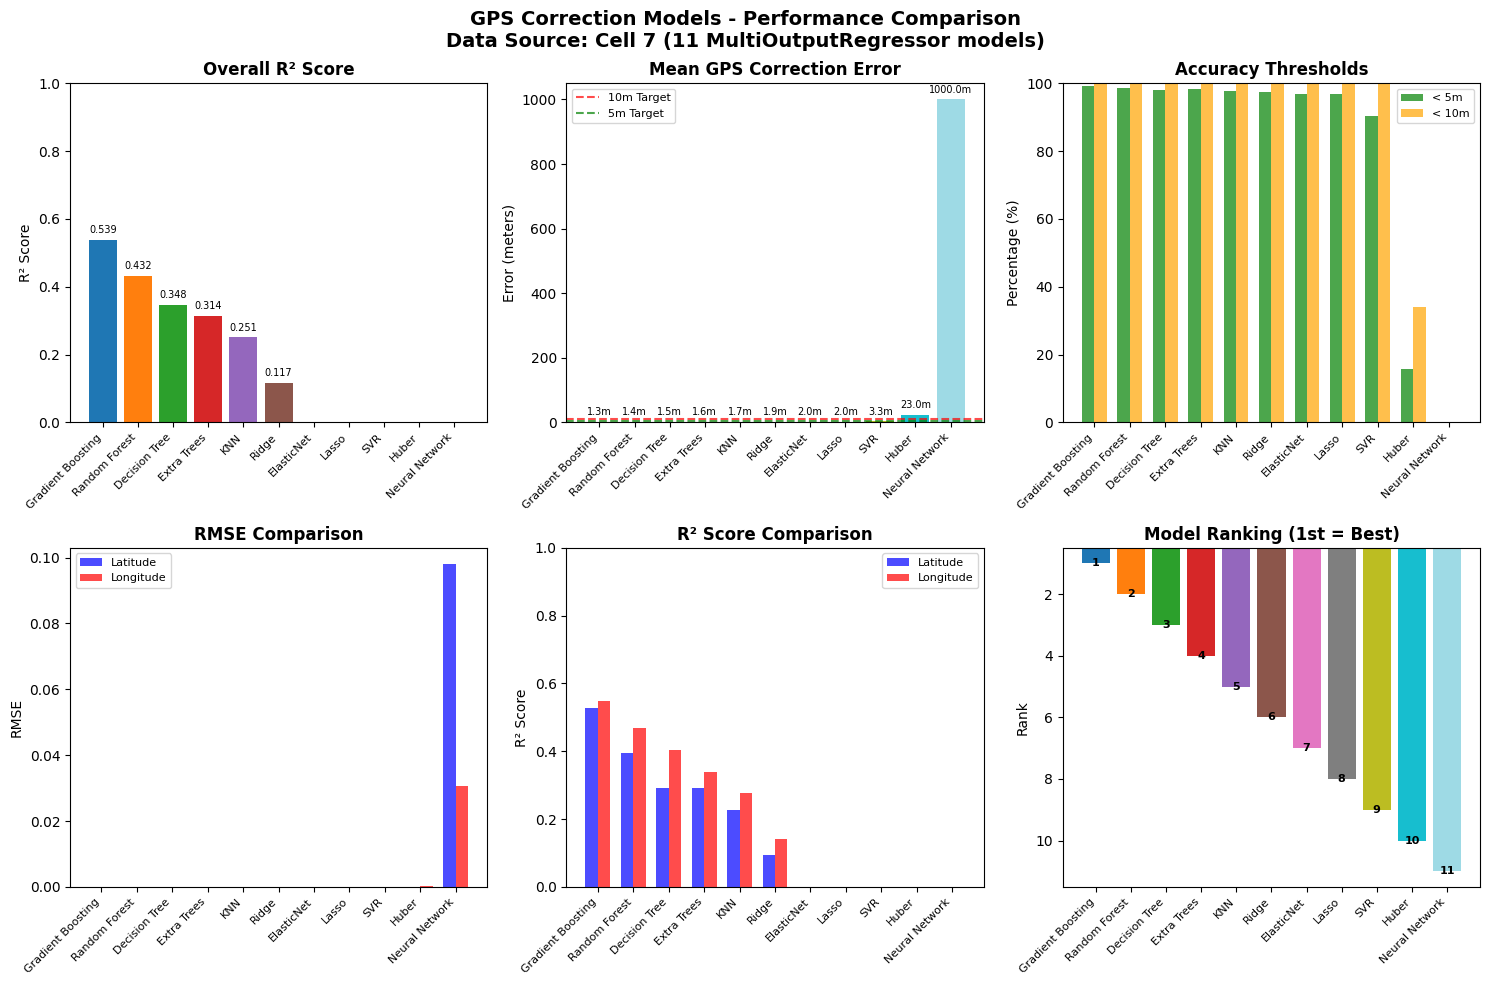


📊 VISUALIZATION SUMMARY:
   📈 Data source: Cell 7 (11 MultiOutputRegressor models)
   🔢 Models visualized: 11
   🏆 Best model: Gradient Boosting
   📍 Best GPS error: 1.33m
   📈 Best R² score: 0.5388

📊 Creating additional export formats...
   ✅ Additional exports saved:
      • model_comparison_summary.png (high-quality)
      • model_comparison_summary.pdf (vector format)
   ✅ Additional exports saved:
      • model_comparison_summary.png (high-quality)
      • model_comparison_summary.pdf (vector format)


In [15]:
# Cell 10: Visual Model Comparison Dashboard (Fixed PNG Export)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("📊 Creating Visual Model Comparison Dashboard...")

# Check which dataset to use for visualization
if 'final_ranking' in locals() and len(final_ranking) > 0:
    print("✅ Using comprehensive results from Cell 7 evaluation")
    df_viz = final_ranking.copy()
    data_source = "Cell 7 (11 MultiOutputRegressor models)"
elif 'simplified_comparison' in locals():
    print("✅ Using simplified comparison from Cell 9")
    df_viz = simplified_comparison.copy()
    data_source = "Cell 9 (simplified comparison)"
else:
    print("❌ No model comparison data available")
    print("🔄 Please run Cell 6 and Cell 7 first for comprehensive evaluation")
    df_viz = None

if df_viz is not None and len(df_viz) > 0:
    try:
        # Validate and clean data before plotting
        df_viz = df_viz.head(15)  # Limit to top 15 models for better visualization
        
        # Ensure all numeric columns are valid
        numeric_cols = ['Overall_R2', 'Under_5m_%', 'Under_10m_%']
        error_col = 'Mean_GPS_Error_m' if 'Mean_GPS_Error_m' in df_viz.columns else 'Mean_Error_m'
        numeric_cols.append(error_col)
        
        for col in numeric_cols:
            if col in df_viz.columns:
                df_viz[col] = pd.to_numeric(df_viz[col], errors='coerce')
                df_viz[col] = df_viz[col].fillna(0)
                # Cap extreme values to prevent rendering issues
                if col == error_col:
                    df_viz[col] = np.clip(df_viz[col], 0, 1000)  # Cap GPS errors at 1000m
                else:
                    df_viz[col] = np.clip(df_viz[col], 0, 100 if '%' in col else 1)
        
        # Create figure with fixed, reasonable dimensions
        plt.close('all')  # Close any existing figures
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # Fixed reasonable size
        fig.suptitle(f'GPS Correction Models - Performance Comparison\nData Source: {data_source}', 
                     fontsize=14, fontweight='bold')

        # Set consistent style
        plt.style.use('default')
        n_models = len(df_viz)
        colors = plt.cm.tab20(np.linspace(0, 1, n_models))

        # 1. Overall R² Comparison
        ax1 = axes[0, 0]
        try:
            bars1 = ax1.bar(range(n_models), df_viz['Overall_R2'], color=colors)
            ax1.set_title('Overall R² Score', fontweight='bold', fontsize=12)
            ax1.set_ylabel('R² Score')
            ax1.set_ylim(0, 1)
            ax1.set_xticks(range(n_models))
            ax1.set_xticklabels(df_viz['Model'], rotation=45, ha='right', fontsize=8)
            # Add value labels on bars
            for i, v in enumerate(df_viz['Overall_R2']):
                if not np.isnan(v) and v > 0:
                    ax1.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=7)
        except Exception as e:
            ax1.text(0.5, 0.5, f'R² Plot Error:\n{str(e)[:50]}', ha='center', va='center', transform=ax1.transAxes)

        # 2. Mean GPS Error Comparison
        ax2 = axes[0, 1]
        try:
            bars2 = ax2.bar(range(n_models), df_viz[error_col], color=colors)
            ax2.set_title('Mean GPS Correction Error', fontweight='bold', fontsize=12)
            ax2.set_ylabel('Error (meters)')
            ax2.axhline(y=10, color='red', linestyle='--', alpha=0.7, label='10m Target')
            ax2.axhline(y=5, color='green', linestyle='--', alpha=0.7, label='5m Target')
            ax2.set_xticks(range(n_models))
            ax2.set_xticklabels(df_viz['Model'], rotation=45, ha='right', fontsize=8)
            ax2.legend(fontsize=8)
            # Add value labels on bars
            max_error = max(df_viz[error_col])
            for i, v in enumerate(df_viz[error_col]):
                if not np.isnan(v) and v > 0:
                    ax2.text(i, v + max_error * 0.02, f'{v:.1f}m', ha='center', fontsize=7)
        except Exception as e:
            ax2.text(0.5, 0.5, f'GPS Error Plot Error:\n{str(e)[:50]}', ha='center', va='center', transform=ax2.transAxes)

        # 3. Accuracy Threshold Comparison
        ax3 = axes[0, 2]
        try:
            x_pos = np.arange(n_models)
            width = 0.35
            bars3a = ax3.bar(x_pos - width/2, df_viz['Under_5m_%'], width, label='< 5m', color='green', alpha=0.7)
            bars3b = ax3.bar(x_pos + width/2, df_viz['Under_10m_%'], width, label='< 10m', color='orange', alpha=0.7)
            ax3.set_title('Accuracy Thresholds', fontweight='bold', fontsize=12)
            ax3.set_ylabel('Percentage (%)')
            ax3.set_xticks(x_pos)
            ax3.set_xticklabels(df_viz['Model'], rotation=45, ha='right', fontsize=8)
            ax3.legend(fontsize=8)
            ax3.set_ylim(0, 100)
        except Exception as e:
            ax3.text(0.5, 0.5, f'Accuracy Plot Error:\n{str(e)[:50]}', ha='center', va='center', transform=ax3.transAxes)

        # 4. Component-wise RMSE (if available)
        ax4 = axes[1, 0]
        try:
            if 'Lat_RMSE' in df_viz.columns and 'Lng_RMSE' in df_viz.columns:
                bars4a = ax4.bar(x_pos - width/2, df_viz['Lat_RMSE'], width, label='Latitude', color='blue', alpha=0.7)
                bars4b = ax4.bar(x_pos + width/2, df_viz['Lng_RMSE'], width, label='Longitude', color='red', alpha=0.7)
                ax4.legend(fontsize=8)
                ax4.set_ylabel('RMSE')
            else:
                # Use overall RMSE if component-wise not available
                rmse_col = df_viz.get('Overall_RMSE', pd.Series([0]*n_models))
                bars4 = ax4.bar(range(n_models), rmse_col, color=colors)
                ax4.set_ylabel('Overall RMSE')
            ax4.set_title('RMSE Comparison', fontweight='bold', fontsize=12)
            ax4.set_xticks(range(n_models))
            ax4.set_xticklabels(df_viz['Model'], rotation=45, ha='right', fontsize=8)
        except Exception as e:
            ax4.text(0.5, 0.5, f'RMSE Plot Error:\n{str(e)[:50]}', ha='center', va='center', transform=ax4.transAxes)

        # 5. Component-wise R² (if available)
        ax5 = axes[1, 1]
        try:
            if 'Lat_R2' in df_viz.columns and 'Lng_R2' in df_viz.columns:
                bars5a = ax5.bar(x_pos - width/2, df_viz['Lat_R2'], width, label='Latitude', color='blue', alpha=0.7)
                bars5b = ax5.bar(x_pos + width/2, df_viz['Lng_R2'], width, label='Longitude', color='red', alpha=0.7)
                ax5.legend(fontsize=8)
                ax5.set_ylim(0, 1)
            else:
                # Use overall R² if component-wise not available
                bars5 = ax5.bar(range(n_models), df_viz['Overall_R2'], color=colors)
                ax5.set_ylim(0, 1)
            ax5.set_title('R² Score Comparison', fontweight='bold', fontsize=12)
            ax5.set_ylabel('R² Score')
            ax5.set_xticks(range(n_models))
            ax5.set_xticklabels(df_viz['Model'], rotation=45, ha='right', fontsize=8)
        except Exception as e:
            ax5.text(0.5, 0.5, f'R² Plot Error:\n{str(e)[:50]}', ha='center', va='center', transform=ax5.transAxes)

        # 6. Model Ranking Visualization
        ax6 = axes[1, 2]
        try:
            ranking_scores = list(range(1, n_models + 1))  # 1st, 2nd, 3rd, etc.
            bars6 = ax6.bar(range(n_models), ranking_scores, color=colors)
            ax6.set_title('Model Ranking (1st = Best)', fontweight='bold', fontsize=12)
            ax6.set_ylabel('Rank')
            ax6.set_xticks(range(n_models))
            ax6.set_xticklabels(df_viz['Model'], rotation=45, ha='right', fontsize=8)
            ax6.set_ylim(n_models + 0.5, 0.5)  # Invert y-axis so 1st is at top
            for i, rank in enumerate(ranking_scores):
                ax6.text(i, rank, f'{rank}', ha='center', va='center', fontweight='bold', fontsize=8)
        except Exception as e:
            ax6.text(0.5, 0.5, f'Ranking Plot Error:\n{str(e)[:50]}', ha='center', va='center', transform=ax6.transAxes)

        plt.tight_layout()
        
        # IMPORTANT: Save the figure BEFORE showing it to prevent blank exports
        try:
            filename = 'model_comparison_dashboard.png'
            fig.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
            print(f"\n💾 Visual dashboard saved to: {filename}")
        except Exception as save_error:
            print(f"\n⚠️  Could not save dashboard: {save_error}")
        
        # Now show the figure (this will clear it, but we've already saved it)
        plt.show()
            
        # Summary statistics
        print(f"\n📊 VISUALIZATION SUMMARY:")
        print(f"   📈 Data source: {data_source}")
        print(f"   🔢 Models visualized: {len(df_viz)}")
        print(f"   🏆 Best model: {df_viz.iloc[0]['Model']}")
        print(f"   📍 Best GPS error: {df_viz.iloc[0][error_col]:.2f}m")
        print(f"   📈 Best R² score: {df_viz.iloc[0]['Overall_R2']:.4f}")
        
        # Optional: Create an additional high-quality export with different settings
        print(f"\n📊 Creating additional export formats...")
        try:
            # Recreate the figure for additional exports (since plt.show() cleared it)
            fig2, axes2 = plt.subplots(2, 3, figsize=(15, 10))
            fig2.suptitle(f'GPS Correction Models - Performance Comparison\nData Source: {data_source}', 
                         fontsize=14, fontweight='bold')
            
            # Quickly recreate key plots for export
            # R² plot
            axes2[0, 0].bar(range(n_models), df_viz['Overall_R2'], color=colors)
            axes2[0, 0].set_title('Overall R² Score', fontweight='bold', fontsize=12)
            axes2[0, 0].set_ylabel('R² Score')
            axes2[0, 0].set_xticks(range(n_models))
            axes2[0, 0].set_xticklabels(df_viz['Model'], rotation=45, ha='right', fontsize=8)
            
            # GPS Error plot
            axes2[0, 1].bar(range(n_models), df_viz[error_col], color=colors)
            axes2[0, 1].set_title('Mean GPS Correction Error', fontweight='bold', fontsize=12)
            axes2[0, 1].set_ylabel('Error (meters)')
            axes2[0, 1].axhline(y=10, color='red', linestyle='--', alpha=0.7, label='10m Target')
            axes2[0, 1].axhline(y=5, color='green', linestyle='--', alpha=0.7, label='5m Target')
            axes2[0, 1].set_xticks(range(n_models))
            axes2[0, 1].set_xticklabels(df_viz['Model'], rotation=45, ha='right', fontsize=8)
            axes2[0, 1].legend(fontsize=8)
            
            # Accuracy plot
            x_pos = np.arange(n_models)
            width = 0.35
            axes2[0, 2].bar(x_pos - width/2, df_viz['Under_5m_%'], width, label='< 5m', color='green', alpha=0.7)
            axes2[0, 2].bar(x_pos + width/2, df_viz['Under_10m_%'], width, label='< 10m', color='orange', alpha=0.7)
            axes2[0, 2].set_title('Accuracy Thresholds', fontweight='bold', fontsize=12)
            axes2[0, 2].set_ylabel('Percentage (%)')
            axes2[0, 2].set_xticks(x_pos)
            axes2[0, 2].set_xticklabels(df_viz['Model'], rotation=45, ha='right', fontsize=8)
            axes2[0, 2].legend(fontsize=8)
            
            # Hide unused subplots
            for i in range(3):
                axes2[1, i].axis('off')
                
            plt.tight_layout()
            
            # Save additional formats
            fig2.savefig('model_comparison_summary.png', dpi=300, bbox_inches='tight', facecolor='white')
            fig2.savefig('model_comparison_summary.pdf', bbox_inches='tight', facecolor='white')
            plt.close(fig2)  # Close this figure to free memory
            
            print(f"   ✅ Additional exports saved:")
            print(f"      • model_comparison_summary.png (high-quality)")
            print(f"      • model_comparison_summary.pdf (vector format)")
            
        except Exception as export_error:
            print(f"   ⚠️  Additional exports failed: {export_error}")
        
    except Exception as main_error:
        print(f"❌ Visualization failed: {main_error}")
        print("🔄 Please ensure all previous cells have been executed successfully")
        
else:
    print("⚠️  Cannot create visualization without model comparison data")
    print("🔄 Please ensure Cell 6 and Cell 7 have been executed successfully")